LOGISTIC REGRESSION FROM SCRATCH
Iteration    0, Cost: 0.693147
Iteration  100, Cost: 0.380782
Iteration  200, Cost: 0.345887
Iteration  300, Cost: 0.334384
Iteration  400, Cost: 0.329326
Iteration  500, Cost: 0.326772
Iteration  600, Cost: 0.325375
Iteration  700, Cost: 0.324569
Iteration  800, Cost: 0.324087
Iteration  900, Cost: 0.323791

TEST RESULTS
Accuracy: 0.8800 (88.0%)

Cost decreased from 0.6931 to 0.3236


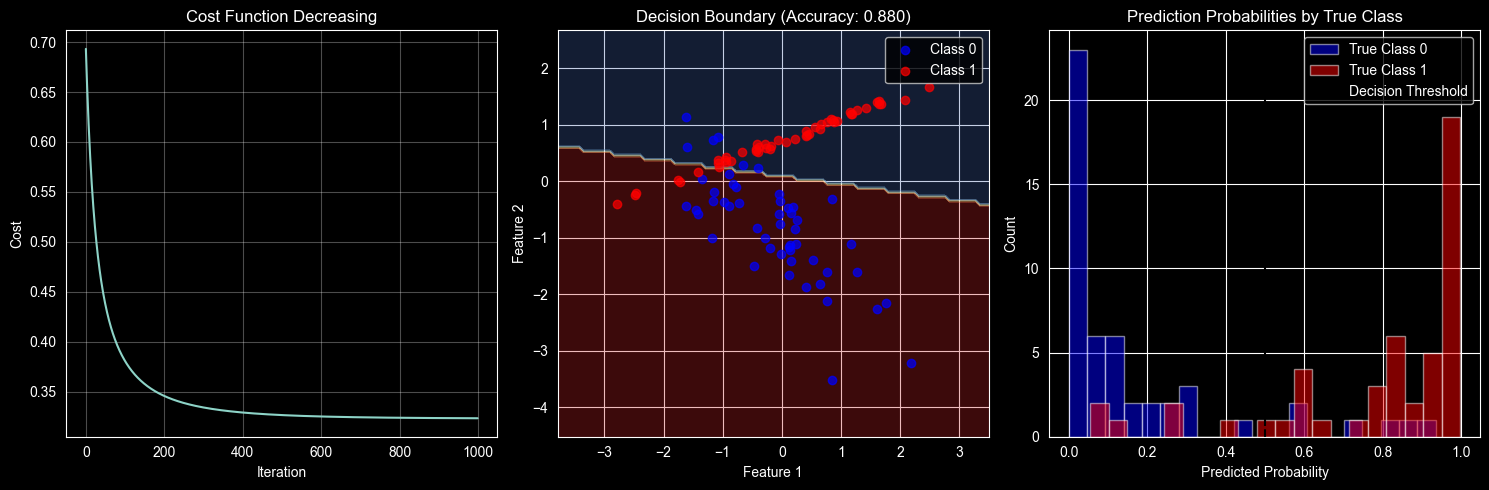


KEY INSIGHTS
1. Gradient descent for logistic regression uses SAME update rule as linear regression
2. The only difference is the prediction: sigmoid(w*X + b) instead of w*X + b
3. Decision boundary separates the two classes
4. Good models have: blue histogram < 0.5, red histogram > 0.5


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ============================================
# PART 1: THE CORE FUNCTIONS (from Days 1-2)
# ============================================

def sigmoid(z):
    """Convert z to probability between 0 and 1"""
    return 1 / (1 + np.exp(-z))

def logistic_cost(y_true, y_pred_prob):
    """Calculate log loss"""
    epsilon = 1e-15
    y_pred_prob = np.clip(y_pred_prob, epsilon, 1 - epsilon)
    m = len(y_true)
    cost = -1/m * np.sum(y_true * np.log(y_pred_prob) + (1 - y_true) * np.log(1 - y_pred_prob))
    return cost

# ============================================
# PART 2: LOGISTIC REGRESSION CLASS
# ============================================

class LogisticRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        """
        Train logistic regression using gradient descent

        Parameters:
        X: training features (n_samples, n_features)
        y: training labels (n_samples,)
        """
        n_samples, n_features = X.shape

        # Initialize parameters
        self.weights = np.zeros((n_features, 1))
        self.bias = 0

        for iteration in range(self.n_iterations):
            # Step 1: Calculate linear output (z = w*X + b)
            z = np.dot(X, self.weights) + self.bias

            # Step 2: Convert to probability using sigmoid
            y_pred_prob = sigmoid(z)

            # Step 3: Calculate cost (log loss)
            cost = logistic_cost(y.reshape(-1, 1), y_pred_prob)
            self.cost_history.append(cost)

            # Step 4: Calculate gradients
            # For logistic regression, dw = (1/m) * X.T * (y_pred - y)
            error = y_pred_prob - y.reshape(-1, 1)
            dw = (1/n_samples) * np.dot(X.T, error)
            db = (1/n_samples) * np.sum(error)

            # Step 5: Update parameters (SAME as linear regression!)
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Print progress
            if iteration % 100 == 0:
                print(f"Iteration {iteration:4d}, Cost: {cost:.6f}")

        return self

    def predict_proba(self, X):
        """Return probability predictions"""
        z = np.dot(X, self.weights) + self.bias
        return sigmoid(z)

    def predict(self, X, threshold=0.5):
        """Return class predictions (0 or 1)"""
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

# ============================================
# PART 3: TEST ON SYNTHETIC DATA
# ============================================

print("=" * 60)
print("LOGISTIC REGRESSION FROM SCRATCH")
print("=" * 60)

# Generate synthetic dataset for binary classification
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for gradient descent)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegressionGD(learning_rate=0.1, n_iterations=1000)
model.fit(X_train_scaled, y_train)

# Predict
y_pred_proba = model.predict_proba(X_test_scaled)
y_pred = model.predict(X_test_scaled)

# Calculate accuracy
accuracy = np.mean(y_pred.flatten() == y_test)
print(f"\n{'='*60}")
print(f"TEST RESULTS")
print(f"{'='*60}")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")

# Calculate cost improvement
print(f"\nCost decreased from {model.cost_history[0]:.4f} to {model.cost_history[-1]:.4f}")

# ============================================
# PART 4: VISUALIZE RESULTS
# ============================================
import os
os.makedirs('week3_logistic_regression', exist_ok=True)


plt.figure(figsize=(15, 5))

# Plot 1: Cost history
plt.subplot(1, 3, 1)
plt.plot(model.cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost Function Decreasing')
plt.grid(True, alpha=0.3)

# Plot 2: Decision boundary
plt.subplot(1, 3, 2)
# Create mesh grid for decision boundary
x_min, x_max = X_test_scaled[:, 0].min() - 1, X_test_scaled[:, 0].max() + 1
y_min, y_max = X_test_scaled[:, 1].min() - 1, X_test_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
plt.scatter(X_test_scaled[y_test == 0][:, 0], X_test_scaled[y_test == 0][:, 1],
            c='blue', label='Class 0', alpha=0.7)
plt.scatter(X_test_scaled[y_test == 1][:, 0], X_test_scaled[y_test == 1][:, 1],
            c='red', label='Class 1', alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Decision Boundary (Accuracy: {accuracy:.3f})')
plt.legend()

# Plot 3: Probability distribution
plt.subplot(1, 3, 3)
plt.hist(y_pred_proba[y_test == 0], bins=20, alpha=0.5, label='True Class 0', color='blue')
plt.hist(y_pred_proba[y_test == 1], bins=20, alpha=0.5, label='True Class 1', color='red')
plt.axvline(x=0.5, color='black', linestyle='--', label='Decision Threshold')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Prediction Probabilities by True Class')
plt.legend()

plt.tight_layout()
plt.savefig('week3_logistic_regression/logistic_regression_results.png')
plt.show()

print("\n" + "=" * 60)
print("KEY INSIGHTS")
print("=" * 60)
print("1. Gradient descent for logistic regression uses SAME update rule as linear regression")
print("2. The only difference is the prediction: sigmoid(w*X + b) instead of w*X + b")
print("3. Decision boundary separates the two classes")
print("4. Good models have: blue histogram < 0.5, red histogram > 0.5")